In [1]:
%pip install pandas selenium webdriver-manager

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# 크롤링할 특정 영화 URL
url = "https://www.imdb.com/title/tt4574334/reviews/?ref_=tt_ov_ql_2"

# 크롬 옵션 설정
options = Options()
options.add_argument("--headless")
options.add_argument("--disable-gpu")
options.add_argument("--no-sandbox")
options.add_argument("--start-maximized")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36")

# 드라이버 실행
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

print(f"🎬 크롤링 시작: {url}")
driver.get(url)
time.sleep(3)

# All 버튼 클릭
try:
    all_button = WebDriverWait(driver, 10).until(
        EC.element_to_be_clickable((By.XPATH, '//span[text()="All"]/ancestor::button'))
    )
    driver.execute_script("arguments[0].click();", all_button)
    print("✅ 'All' 버튼 클릭 완료")
    time.sleep(3)
except Exception as e:
    print("❌ 'All' 버튼 클릭 실패:", e)

# Load More 버튼을 1-2번만 클릭 (페이지 추가 로드)
load_more_clicks = 2  # 원하는 만큼 조정 가능
for i in range(load_more_clicks):
    try:
        load_more_button = WebDriverWait(driver, 5).until(
            EC.element_to_be_clickable((By.XPATH, '//button[contains(., "Load More")]'))
        )
        driver.execute_script("arguments[0].click();", load_more_button)
        print(f"✅ 'Load More' 버튼 클릭 {i+1}회")
        time.sleep(3)
    except Exception as e:
        print(f"⚠️ 'Load More' 버튼 없음 또는 클릭 실패 ({i+1}회): {e}")
        break

# 스포일러 버튼 클릭
try:
    spoiler_buttons = driver.find_elements(By.XPATH, '//button[.//span[text()="Spoiler"]]')
    print(f"📢 스포일러 버튼 개수: {len(spoiler_buttons)}")
    for btn in spoiler_buttons:
        try:
            driver.execute_script("arguments[0].click();", btn)
            time.sleep(0.2)
        except:
            continue
    print("✅ 모든 스포일러 버튼 클릭 완료")
except Exception as e:
    print("❌ 스포일러 버튼 클릭 중 오류:", e)

# 리뷰 수집
data = []
review_containers = driver.find_elements(By.CLASS_NAME, "user-review-item")
print(f"📝 총 리뷰 개수: {len(review_containers)}개")

for container in review_containers:
    try:
        rating = container.find_element(By.CLASS_NAME, "ipc-rating-star--rating").text.strip()
    except:
        rating = "N/A"
    
    try:
        title = container.find_element(By.TAG_NAME, "a").text.strip()
    except:
        title = "N/A"
    
    try:
        spoiler_div = container.find_element(By.CLASS_NAME, "ipc-html-content-inner-div")
        body = spoiler_div.text.strip()
    except:
        try:
            text_element = container.find_element(By.CSS_SELECTOR, 'div[data-testid="review-overflow"]')
            body = text_element.text.strip()
        except:
            body = "N/A"
    
    data.append({
        "Rating": rating,
        "Title": title,
        "Content": body
    })

# CSV 저장
df = pd.DataFrame(data)
output_file = "imdb_reviews_sample.csv"
df.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"\n💾 CSV 저장 완료: {output_file}")
print(f"📊 수집된 리뷰: {len(data)}개")

# 드라이버 종료
driver.quit()

🎬 크롤링 시작: https://www.imdb.com/title/tt4574334/reviews/?ref_=tt_ov_ql_2
❌ 'All' 버튼 클릭 실패: Message: 
Stacktrace:
	GetHandleVerifier [0x0xf1fe43+66515]
	GetHandleVerifier [0x0xf1fe84+66580]
	(No symbol) [0x0xd0dc48]
	(No symbol) [0x0xd58704]
	(No symbol) [0x0xd58aab]
	(No symbol) [0x0xd9f482]
	(No symbol) [0x0xd7b214]
	(No symbol) [0x0xd9cba7]
	(No symbol) [0x0xd7afc6]
	(No symbol) [0x0xd4c2ca]
	(No symbol) [0x0xd4d154]
	GetHandleVerifier [0x0x1177353+2521315]
	GetHandleVerifier [0x0x11722d3+2500707]
	GetHandleVerifier [0x0xf47c94+229924]
	GetHandleVerifier [0x0xf381f8+165768]
	GetHandleVerifier [0x0xf3ecad+193085]
	GetHandleVerifier [0x0xf28158+100072]
	GetHandleVerifier [0x0xf282f0+100480]
	GetHandleVerifier [0x0xf125aa+11066]
	BaseThreadInitThunk [0x0x75d35d49+25]
	RtlInitializeExceptionChain [0x0x77ccd6db+107]
	RtlGetAppContainerNamedObjectPath [0x0x77ccd661+561]

⚠️ 'Load More' 버튼 없음 또는 클릭 실패 (1회): Message: 
Stacktrace:
	GetHandleVerifier [0x0xf1fe43+66515]
	GetHandleVerifier [0x0xf

In [4]:
# -*- coding: utf-8 -*-
import pandas as pd
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

# 크롤링할 특정 영화 URL
url = "https://www.imdb.com/title/tt4574334/reviews/?ref_=tt_ov_ql_2"

# 크롬 옵션 설정
options = Options()
options.add_argument("--headless")
options.add_argument("--disable-gpu")
options.add_argument("--no-sandbox")
options.add_argument("--start-maximized")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36")

# 드라이버 실행
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

print(f"🎬 크롤링 시작: {url}")
driver.get(url)
time.sleep(3)

# 25 more 버튼을 1-2번 클릭 (원하는 만큼 조정)
more_button_clicks = 2  # 25개씩 2번 = 약 50개 추가 로드
for i in range(more_button_clicks):
    try:
        more_button = WebDriverWait(driver, 10).until(
            EC.element_to_be_clickable((By.XPATH, '//*[@id="__next"]/main/div/section/div/section/div/div[1]/section[1]/div[3]/div/span[1]/button/span'))
        )
        driver.execute_script("arguments[0].click();", more_button)
        print(f"✅ '25 more' 버튼 클릭 {i+1}회")
        time.sleep(3)
    except Exception as e:
        print(f"⚠️ '25 more' 버튼 없음 또는 클릭 실패 ({i+1}회): {e}")
        break

# 스포일러 버튼 클릭
try:
    spoiler_buttons = driver.find_elements(By.XPATH, '//button[.//span[text()="Spoiler"]]')
    print(f"📢 스포일러 버튼 개수: {len(spoiler_buttons)}")
    for btn in spoiler_buttons:
        try:
            driver.execute_script("arguments[0].click();", btn)
            time.sleep(0.2)
        except:
            continue
    print("✅ 모든 스포일러 버튼 클릭 완료")
except Exception as e:
    print("❌ 스포일러 버튼 클릭 중 오류:", e)

# 리뷰 수집
print("\n📝 리뷰 수집 중...")
data = []
review_containers = driver.find_elements(By.CLASS_NAME, "user-review-item")
print(f"총 {len(review_containers)}개의 리뷰 발견")

for idx, container in enumerate(review_containers, 1):
    try:
        rating = container.find_element(By.CLASS_NAME, "ipc-rating-star--rating").text.strip()
    except:
        rating = "N/A"
    
    try:
        title = container.find_element(By.TAG_NAME, "a").text.strip()
    except:
        title = "N/A"
    
    try:
        spoiler_div = container.find_element(By.CLASS_NAME, "ipc-html-content-inner-div")
        body = spoiler_div.text.strip()
    except:
        try:
            text_element = container.find_element(By.CSS_SELECTOR, 'div[data-testid="review-overflow"]')
            body = text_element.text.strip()
        except:
            body = "N/A"
    
    data.append({
        "Review_Number": idx,
        "Rating": rating,
        "Title": title,
        "Content": body,
        "Content_Length": len(body) if body != "N/A" else 0
    })
    
    if idx % 10 == 0:
        print(f"  - {idx}개 리뷰 처리 완료...")

# 드라이버 종료
driver.quit()

# DataFrame 생성 및 정리
print("\n📊 DataFrame 생성 중...")
df = pd.DataFrame(data)

# 데이터 정보 출력
print("\n" + "="*60)
print("📈 수집된 데이터 요약")
print("="*60)
print(f"총 리뷰 수: {len(df)}개")
print(f"\n평점 분포:")
print(df['Rating'].value_counts().sort_index())
print(f"\n기본 통계:")
print(df.describe(include='all'))
print("\n" + "="*60)

# 샘플 데이터 미리보기
print("\n🔍 데이터 미리보기 (처음 3개):")
print(df.head(3).to_string())

# CSV 저장
output_file = "imdb_reviews_sample.csv"
df.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"\n💾 CSV 저장 완료: {output_file}")
print(f"📁 저장 위치: {output_file}")
print(f"✅ 총 {len(df)}개의 리뷰가 저장되었습니다!")

🎬 크롤링 시작: https://www.imdb.com/title/tt4574334/reviews/?ref_=tt_ov_ql_2
✅ '25 more' 버튼 클릭 1회
✅ '25 more' 버튼 클릭 2회
📢 스포일러 버튼 개수: 11
✅ 모든 스포일러 버튼 클릭 완료

📝 리뷰 수집 중...
총 75개의 리뷰 발견
  - 10개 리뷰 처리 완료...
  - 20개 리뷰 처리 완료...
  - 30개 리뷰 처리 완료...
  - 40개 리뷰 처리 완료...
  - 50개 리뷰 처리 완료...
  - 60개 리뷰 처리 완료...
  - 70개 리뷰 처리 완료...

📊 DataFrame 생성 중...

📈 수집된 데이터 요약
총 리뷰 수: 75개

평점 분포:
Rating
10     31
3       1
4       2
5       3
6       4
7       3
8       5
9      21
N/A     5
Name: count, dtype: int64

기본 통계:
        Review_Number Rating                                    Title  \
count       75.000000     75                                       75   
unique            NaN      9                                       75   
top               NaN     10  One of the best supernatural shows ever   
freq              NaN     31                                        1   
mean        38.000000    NaN                                      NaN   
std         21.794495    NaN                               

📂 CSV 파일 로드 완료: imdb_reviews_sample.csv
총 75개의 리뷰 데이터

☁️ 워드클라우드 생성 중...
💾 워드클라우드 저장 완료: imdb_reviews_wordcloud.png


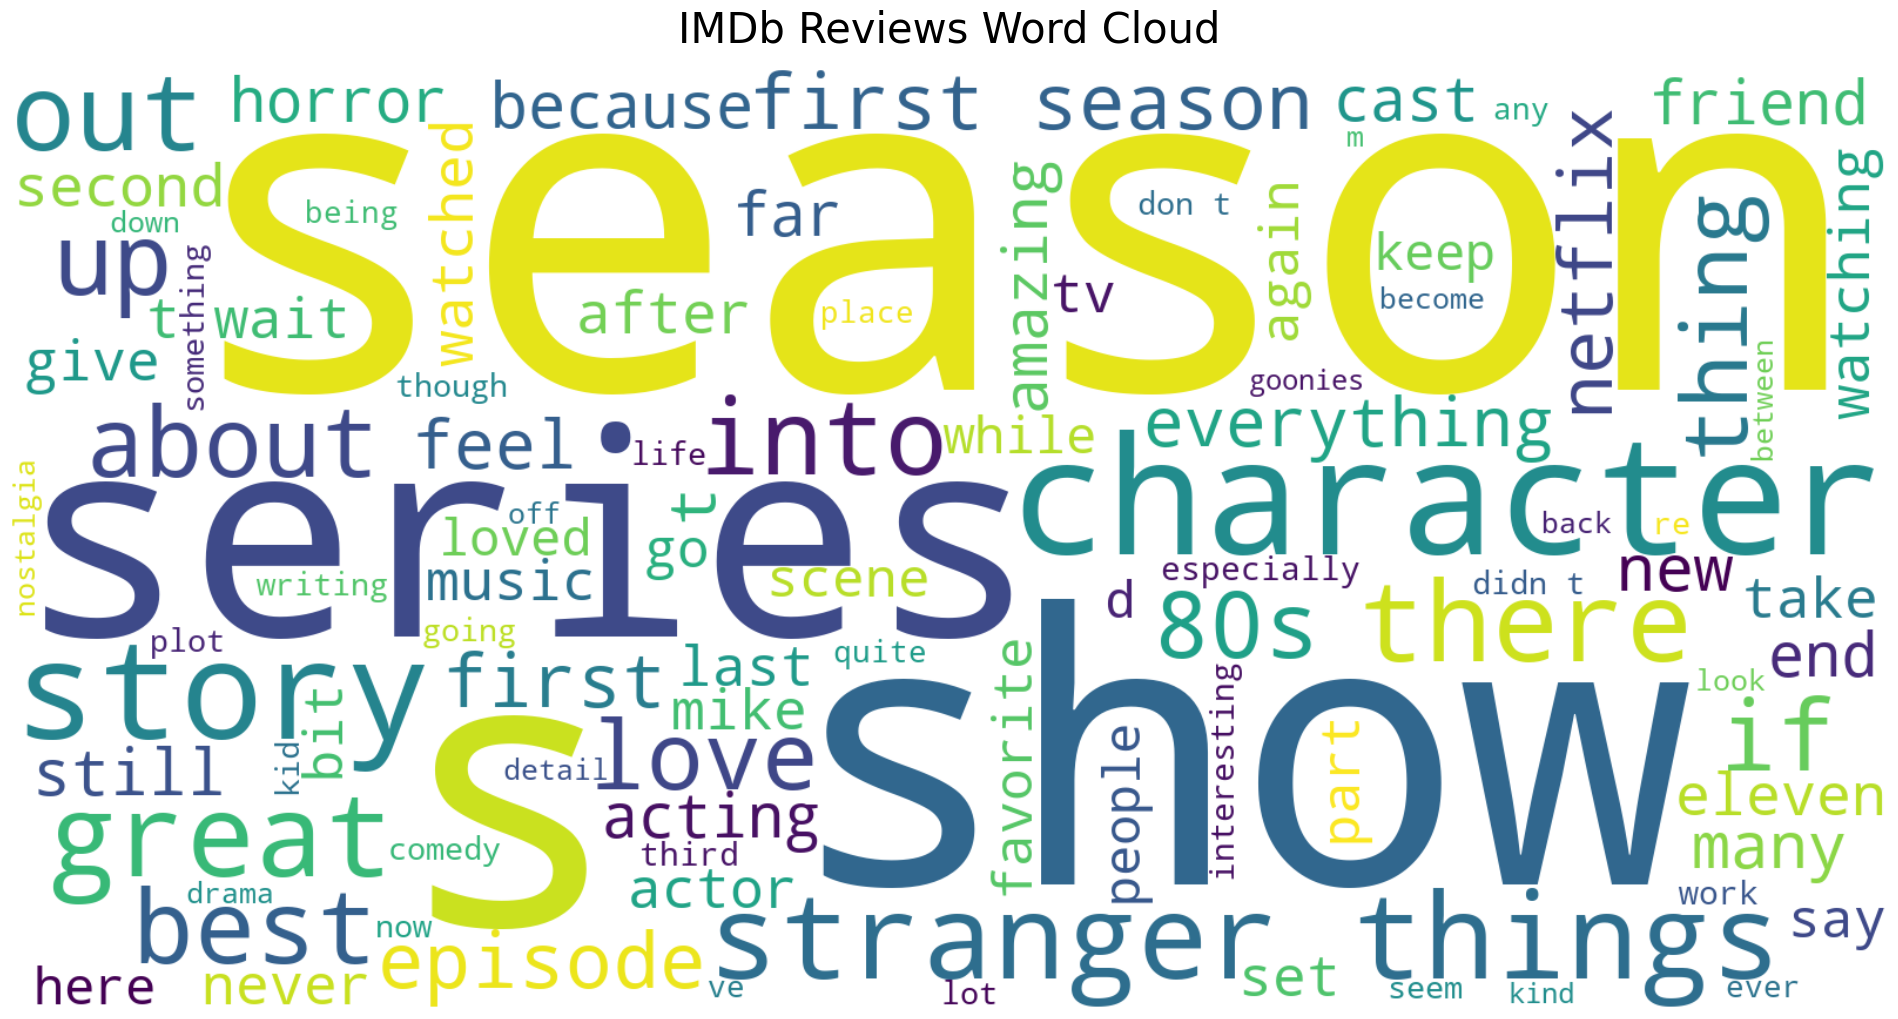


📊 단어 빈도수 분석...

🔝 가장 많이 등장한 단어 Top 30:
   1. season               :  180회
   2. show                 :  103회
   3. series               :   69회
   4. first                :   52회
   5. things               :   47회
   6. characters           :   43회
   7. stranger             :   39회
   8. story                :   38회
   9. out                  :   37회
  10. great                :   35회
  11. there                :   33회
  12. into                 :   29회
  13. love                 :   28회
  14. best                 :   28회
  15. seasons              :   28회
  16. about                :   26회
  17. 80s                  :   24회
  18. netflix              :   21회
  19. episode              :   21회
  20. everything           :   21회
  21. wait                 :   20회
  22. many                 :   19회
  23. new                  :   19회
  24. still                :   19회
  25. because              :   18회
  26. character            :   18회
  27. far                  :   17회
  28. cast     

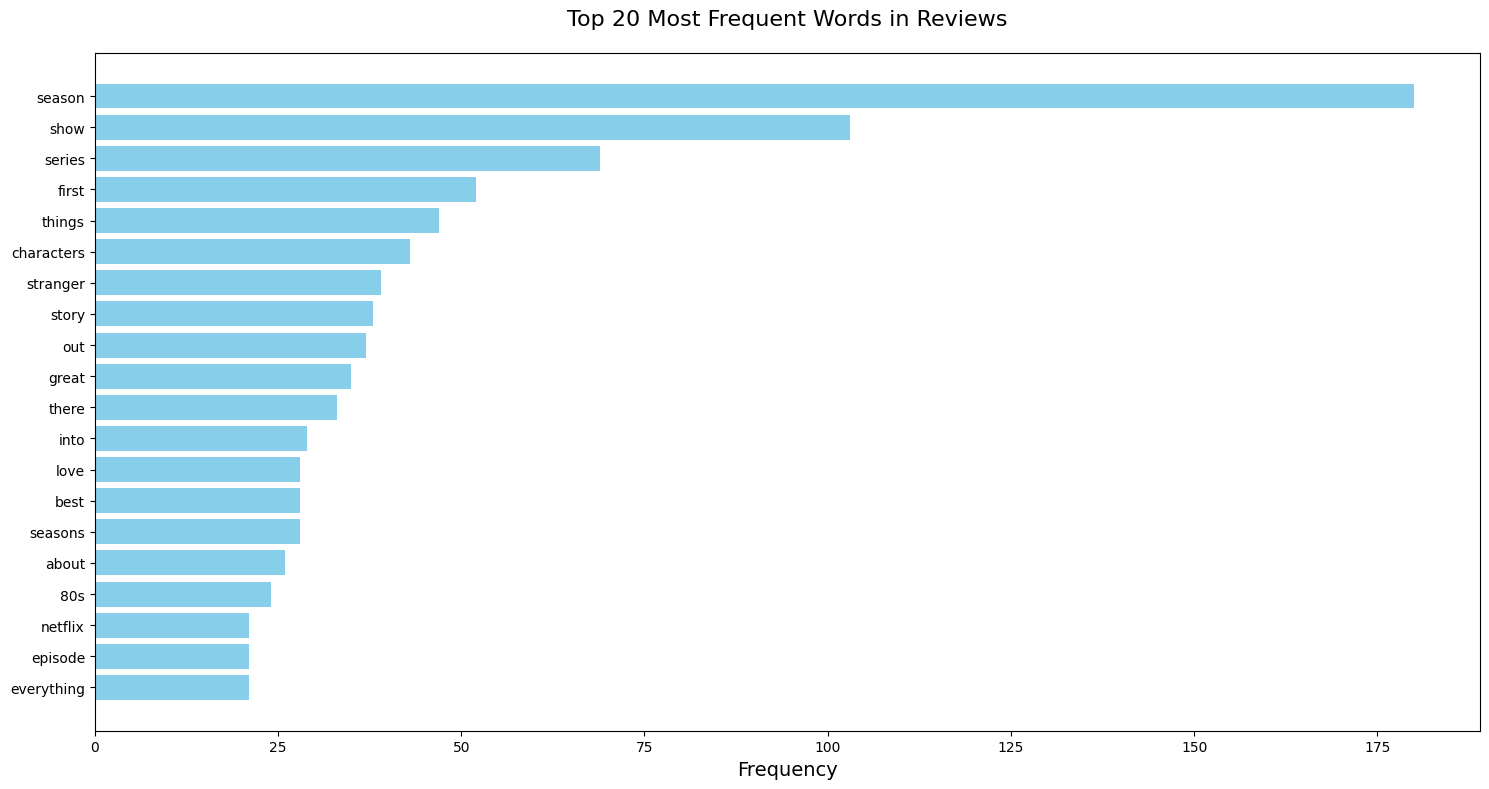


✅ 모든 작업 완료!
📁 생성된 파일:
   - imdb_reviews_wordcloud.png


In [5]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re

# CSV 파일 읽기
csv_file = "imdb_reviews_sample.csv"
df = pd.read_csv(csv_file, encoding='utf-8-sig')

print(f"📂 CSV 파일 로드 완료: {csv_file}")
print(f"총 {len(df)}개의 리뷰 데이터")

# ============================================================
# 워드클라우드 생성
# ============================================================
print("\n☁️ 워드클라우드 생성 중...")

# 모든 리뷰 텍스트 합치기
all_text = " ".join(df[df['Content'] != 'N/A']['Content'].astype(str))

# 텍스트 전처리 (소문자 변환, 특수문자 제거)
all_text = all_text.lower()
all_text = re.sub(r'[^\w\s]', ' ', all_text)

# 불용어 리스트 (일반적인 영어 불용어)
stopwords = set(['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 
                 'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were', 'been',
                 'be', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
                 'could', 'should', 'may', 'might', 'must', 'can', 'this', 'that',
                 'these', 'those', 'i', 'you', 'he', 'she', 'it', 'we', 'they',
                 'my', 'your', 'his', 'her', 'its', 'our', 'their', 'me', 'him',
                 'them', 'what', 'which', 'who', 'when', 'where', 'why', 'how',
                 'all', 'each', 'every', 'both', 'few', 'more', 'most', 'other',
                 'some', 'such', 'no', 'not', 'only', 'own', 'same', 'so', 'than',
                 'too', 'very', 'just', 'one', 'two', 'also', 'movie', 'film',
                 'like', 'get', 'even', 'really', 'much', 'way', 'good', 'time',
                 'see', 'make', 'made', 'think', 'know', 'want', 'well', 'watch'])

# 워드클라우드 생성
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    stopwords=stopwords,
    max_words=100,
    colormap='viridis',
    relative_scaling=0.5,
    min_font_size=10
).generate(all_text)

# 워드클라우드 시각화
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('IMDb Reviews Word Cloud', fontsize=30, pad=20)
plt.tight_layout(pad=0)

# 이미지 저장
wordcloud_file = "imdb_reviews_wordcloud.png"
plt.savefig(wordcloud_file, dpi=300, bbox_inches='tight')
print(f"💾 워드클라우드 저장 완료: {wordcloud_file}")

# 화면에 표시
plt.show()

# ============================================================
# 빈도수 분석
# ============================================================
print("\n📊 단어 빈도수 분석...")

# 단어 빈도수 계산
words = all_text.split()
words = [word for word in words if word not in stopwords and len(word) > 2]
word_freq = Counter(words).most_common(30)

print("\n🔝 가장 많이 등장한 단어 Top 30:")
print("=" * 50)
for i, (word, freq) in enumerate(word_freq, 1):
    print(f"  {i:2d}. {word:20s} : {freq:4d}회")
print("=" * 50)

# 빈도수 그래프 생성
plt.figure(figsize=(15, 8))
words_top20 = [word for word, freq in word_freq[:20]]
freqs_top20 = [freq for word, freq in word_freq[:20]]

plt.barh(words_top20[::-1], freqs_top20[::-1], color='skyblue')
plt.xlabel('Frequency', fontsize=14)
plt.title('Top 20 Most Frequent Words in Reviews', fontsize=16, pad=20)
plt.tight_layout()

# # 빈도수 그래프 저장
# freq_chart_file = "word_frequency_chart.png"
# plt.savefig(freq_chart_file, dpi=300, bbox_inches='tight')
# print(f"💾 빈도수 차트 저장 완료: {freq_chart_file}")

plt.show()

print("\n✅ 모든 작업 완료!")
print(f"📁 생성된 파일:")
print(f"   - {wordcloud_file}")
# print(f"   - {freq_chart_file}")

In [6]:
# -*- coding: utf-8 -*-
import requests
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
import time

print("=" * 60)
print("🎵 멜론(Melon) 사이트 응답 체크")
print("=" * 60)

# 테스트할 멜론 URL들
melon_urls = [
    "https://www.melon.com",
    "https://www.melon.com/chart/index.htm",
    "https://www.melon.com/chart/day/index.htm",
]

# ============================================================
# 방법 1: requests로 간단히 체크
# ============================================================
print("\n📡 방법 1: requests 라이브러리로 응답 체크")
print("-" * 60)

for url in melon_urls:
    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36'
        }
        response = requests.get(url, headers=headers, timeout=10)
        
        if response.status_code == 200:
            print(f"✅ {url}")
            print(f"   상태 코드: {response.status_code}")
            print(f"   응답 시간: {response.elapsed.total_seconds():.2f}초")
        else:
            print(f"⚠️ {url}")
            print(f"   상태 코드: {response.status_code}")
            
    except requests.exceptions.Timeout:
        print(f"❌ {url}")
        print(f"   오류: 타임아웃 (10초 초과)")
    except requests.exceptions.ConnectionError:
        print(f"❌ {url}")
        print(f"   오류: 연결 실패")
    except Exception as e:
        print(f"❌ {url}")
        print(f"   오류: {e}")
    print()

# ============================================================
# 방법 2: Selenium으로 실제 브라우저 접속 체크
# ============================================================
print("\n🌐 방법 2: Selenium으로 실제 브라우저 접속 체크")
print("-" * 60)

# 크롬 옵션 설정
options = Options()
options.add_argument("--headless")
options.add_argument("--disable-gpu")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0.0.0 Safari/537.36")

try:
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
    
    for url in melon_urls:
        try:
            start_time = time.time()
            driver.get(url)
            time.sleep(2)  # 페이지 로딩 대기
            
            # 페이지 타이틀 가져오기
            title = driver.title
            elapsed_time = time.time() - start_time
            
            print(f"✅ {url}")
            print(f"   페이지 제목: {title}")
            print(f"   로딩 시간: {elapsed_time:.2f}초")
            
            # 페이지 소스 일부 확인
            page_source_length = len(driver.page_source)
            print(f"   페이지 소스 크기: {page_source_length:,} bytes")
            
        except Exception as e:
            print(f"❌ {url}")
            print(f"   오류: {e}")
        print()
    
    driver.quit()
    print("✅ Selenium 드라이버 종료 완료")
    
except Exception as e:
    print(f"❌ Selenium 드라이버 초기화 실패: {e}")

# ============================================================
# 결과 요약
# ============================================================
print("\n" + "=" * 60)
print("📊 체크 완료!")
print("=" * 60)
print("\n💡 참고사항:")
print("   - 멜론은 로그인이 필요한 페이지가 많습니다")
print("   - 크롤링 시 robots.txt 및 이용약관을 확인하세요")
print("   - 과도한 요청은 IP 차단의 원인이 될 수 있습니다")
print("   - 실제 크롤링 시에는 적절한 딜레이를 추가하세요")

🎵 멜론(Melon) 사이트 응답 체크

📡 방법 1: requests 라이브러리로 응답 체크
------------------------------------------------------------
✅ https://www.melon.com
   상태 코드: 200
   응답 시간: 0.62초

✅ https://www.melon.com/chart/index.htm
   상태 코드: 200
   응답 시간: 0.45초

✅ https://www.melon.com/chart/day/index.htm
   상태 코드: 200
   응답 시간: 0.35초


🌐 방법 2: Selenium으로 실제 브라우저 접속 체크
------------------------------------------------------------
✅ https://www.melon.com
   페이지 제목: Melon::음악이 필요한 순간, 멜론
   로딩 시간: 3.44초
   페이지 소스 크기: 264,062 bytes

✅ https://www.melon.com/chart/index.htm
   페이지 제목: 멜론차트>TOP100>멜론
   로딩 시간: 2.66초
   페이지 소스 크기: 458,262 bytes

✅ https://www.melon.com/chart/day/index.htm
   페이지 제목: 멜론차트>일간>장르종합>멜론
   로딩 시간: 2.62초
   페이지 소스 크기: 455,519 bytes

✅ Selenium 드라이버 종료 완료

📊 체크 완료!

💡 참고사항:
   - 멜론은 로그인이 필요한 페이지가 많습니다
   - 크롤링 시 robots.txt 및 이용약관을 확인하세요
   - 과도한 요청은 IP 차단의 원인이 될 수 있습니다
   - 실제 크롤링 시에는 적절한 딜레이를 추가하세요
